## Deteccion de regimenes de mercado

### Veo empresas argentinas


In [8]:
import yfinance as yf
import pandas as pd

tickers = ['YPF', 'GGAL', 'BMA', 'SUPV', 'LOMA', 'CEPU', 'PAM', 'TGS']

start = '2008-01-01'
end = '2025-01-01'

raw = yf.download(
    tickers,
    start=start,
    end=end,
    auto_adjust=False
)

data = raw['Close']
aperturas = raw['Open']
volumen = raw['Volume']

[**********************88%*****************      ]  7 of 8 completed


In [9]:
ticker = 'GGAL'
open_ticker = aperturas[ticker].copy()
close_ticker = data[ticker].copy()

open_ticker.index = open_ticker.index.tz_localize(None)
close_ticker.index = close_ticker.index.tz_localize(None)

gap_overnight = open_ticker / close_ticker.shift(1) - 1
gap_overnight.name = 'gap_overnight'

In [10]:
df_gaps = pd.DataFrame({
    'open': open_ticker,
    'close_anterior': close_ticker.shift(1),
    'gap_overnight': gap_overnight
}).dropna()

umbral = 0.01  # 1%

total_dias = len(df_gaps)

gaps_positivos = (df_gaps['gap_overnight'] > 0).sum()
gaps_negativos = (df_gaps['gap_overnight'] < 0).sum()
gaps_grandes = (df_gaps['gap_overnight'].abs() >= umbral).sum()

gaps_grandes_positivos = (df_gaps['gap_overnight'] >= umbral).sum()
gaps_grandes_negativos = (df_gaps['gap_overnight'] <= -umbral).sum()

print('Total de ruedas analizadas:', total_dias)
print('Gaps positivos:', gaps_positivos)
print('Gaps negativos:', gaps_negativos)
print(f'Gaps mayores a +/- {umbral:.0%}:', gaps_grandes)
print(f'Gaps positivos mayores a {umbral:.0%}:', gaps_grandes_positivos)
print(f'Gaps negativos menores a -{umbral:.0%}:', gaps_grandes_negativos)
print()
print('Porcentaje de gaps grandes:', gaps_grandes / total_dias)

Total de ruedas analizadas: 4278
Gaps positivos: 2208
Gaps negativos: 1819
Gaps mayores a +/- 1%: 1535
Gaps positivos mayores a 1%: 874
Gaps negativos menores a -1%: 661

Porcentaje de gaps grandes: 0.3588125292192613


In [11]:
df_gaps['gap_pct'] = df_gaps['gap_overnight'] * 100

df_gaps.sort_values(
    'gap_overnight',
    key=abs,
    ascending=False
).head(20)

,open,close_anterior,gap_overnight,gap_pct
Date,,,,
2019-08-12,19.309999,38.169998,-0.494105,-49.410531
2008-12-01,1.460000,1.900000,-0.231579,-23.157892
2023-11-20,14.790000,12.500000,0.183200,18.320000
2015-10-26,25.000000,21.299999,0.173709,17.370896
2020-03-16,7.720000,9.210000,-0.161781,-16.178070
2021-09-13,12.220000,10.560000,0.157197,15.719695
2009-01-16,2.400000,2.080000,0.153846,15.384624
2008-12-05,1.540000,1.800000,-0.144444,-14.444444
2010-05-10,5.970000,5.300000,0.126415,12.641501


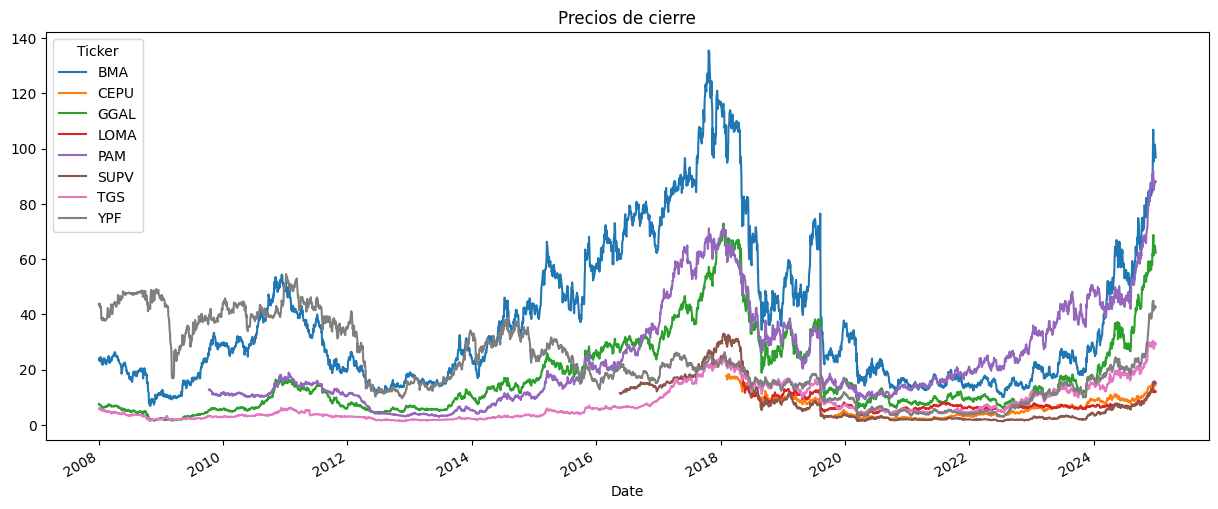

In [12]:
import matplotlib.pyplot as plt

data.plot(figsize=(15, 6), title='Precios de cierre')
plt.show()

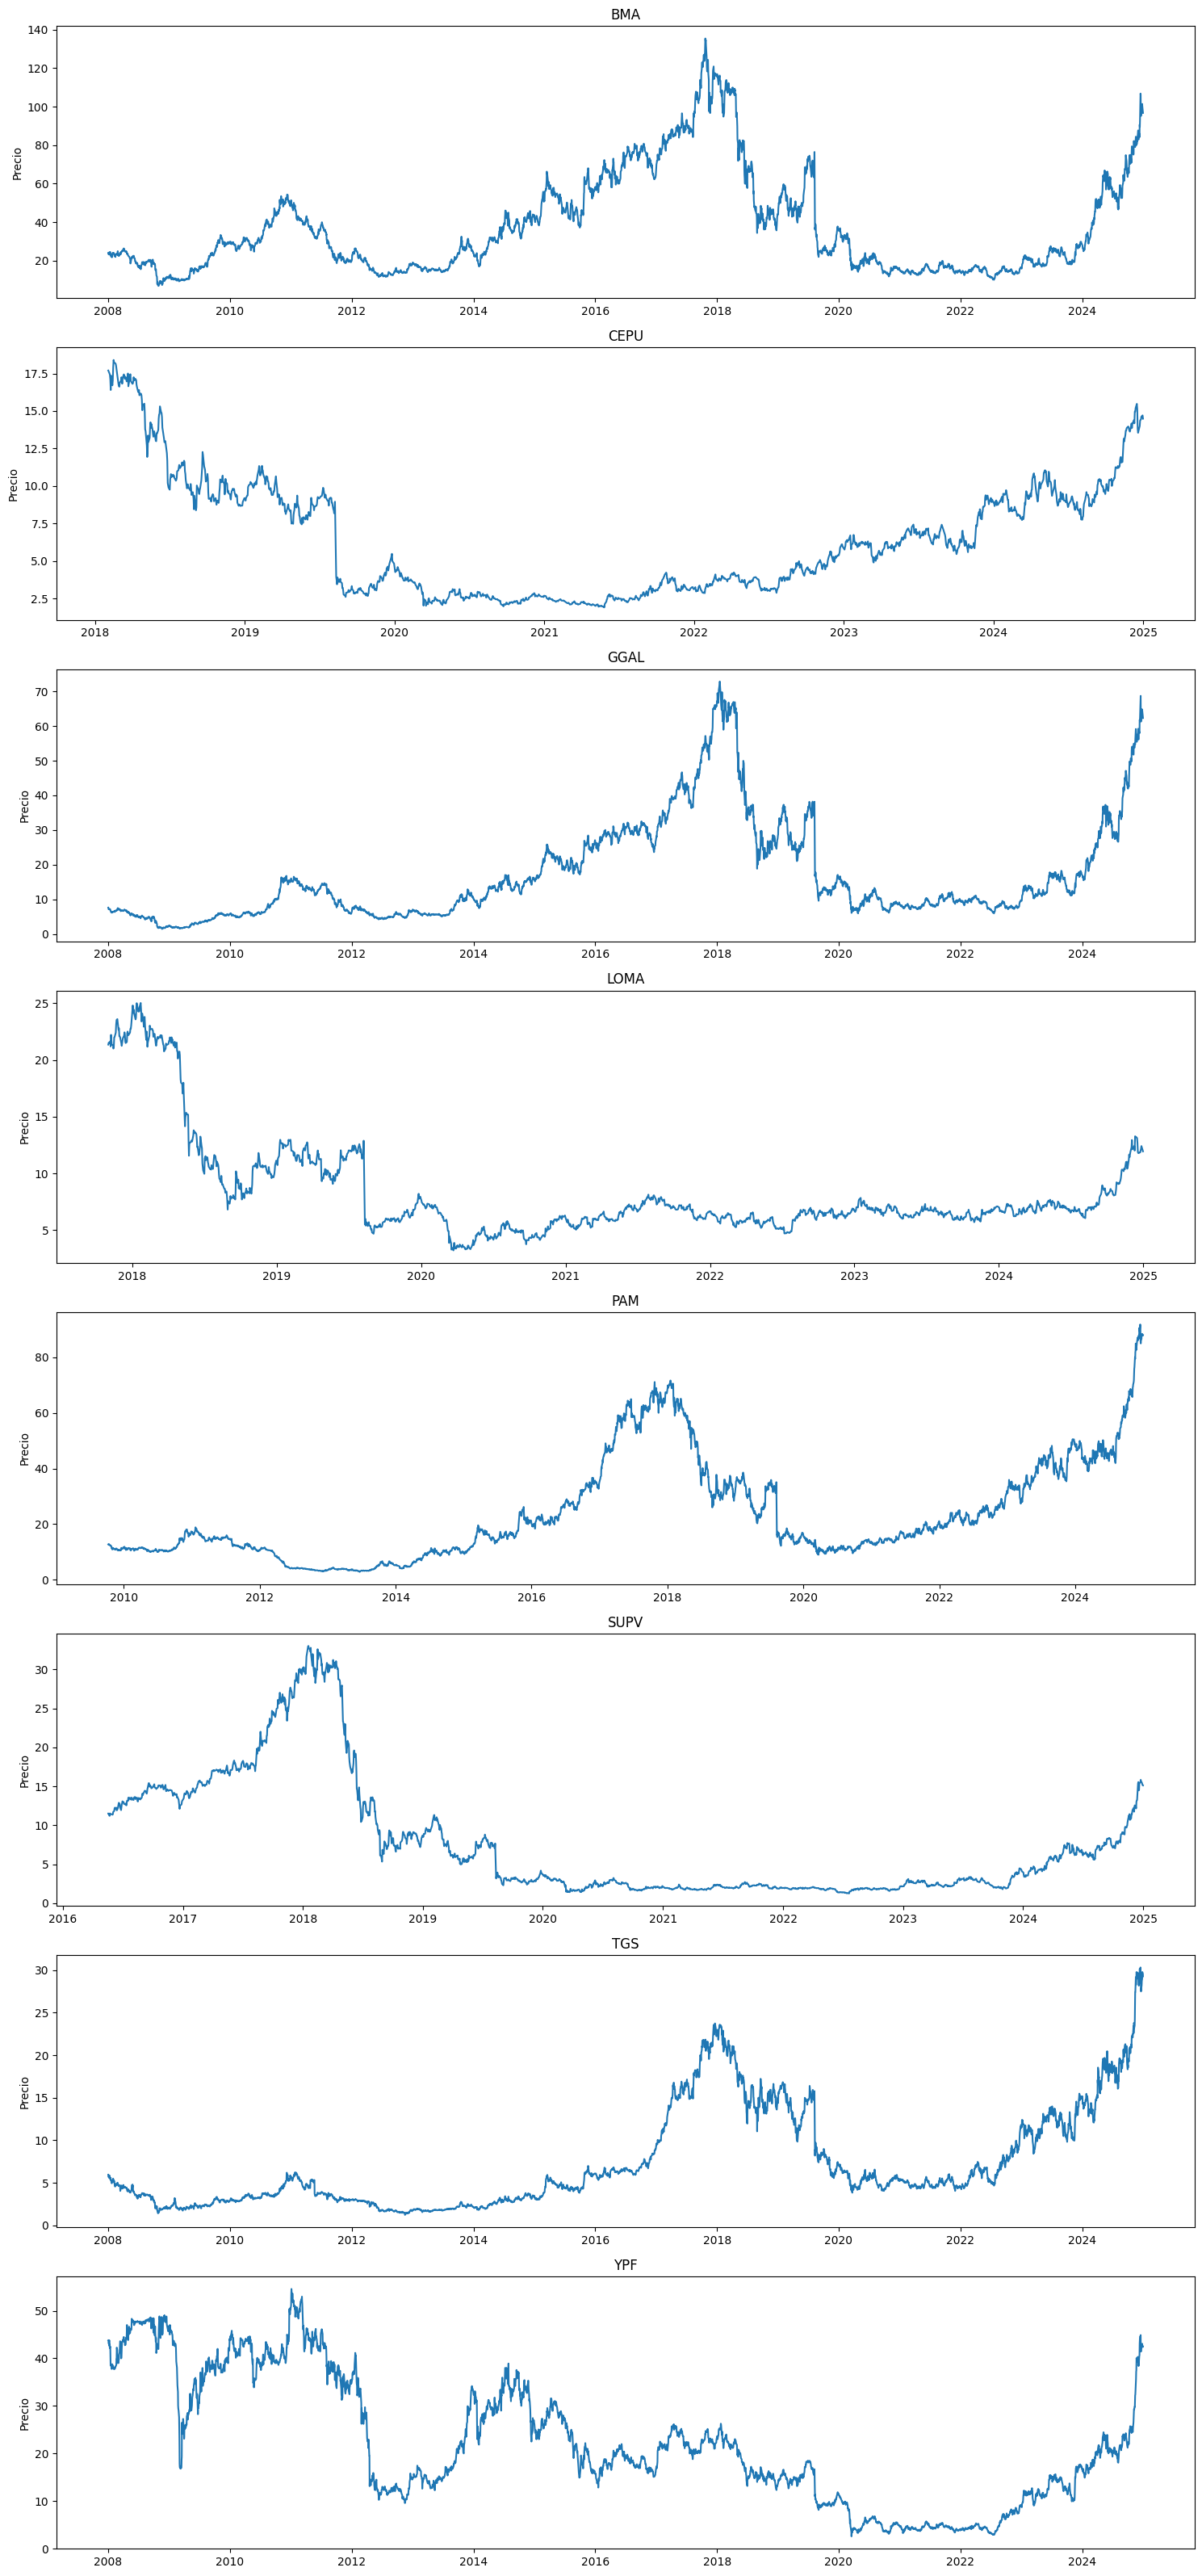

In [13]:
fig, axes = plt.subplots(len(data.columns), 1, figsize=(15, 4 * len(data.columns)))

for i, ticker in enumerate(data.columns):
    axes[i].plot(data.index, data[ticker])
    axes[i].set_title(ticker)
    axes[i].set_ylabel('Precio')

plt.tight_layout()
plt.show()

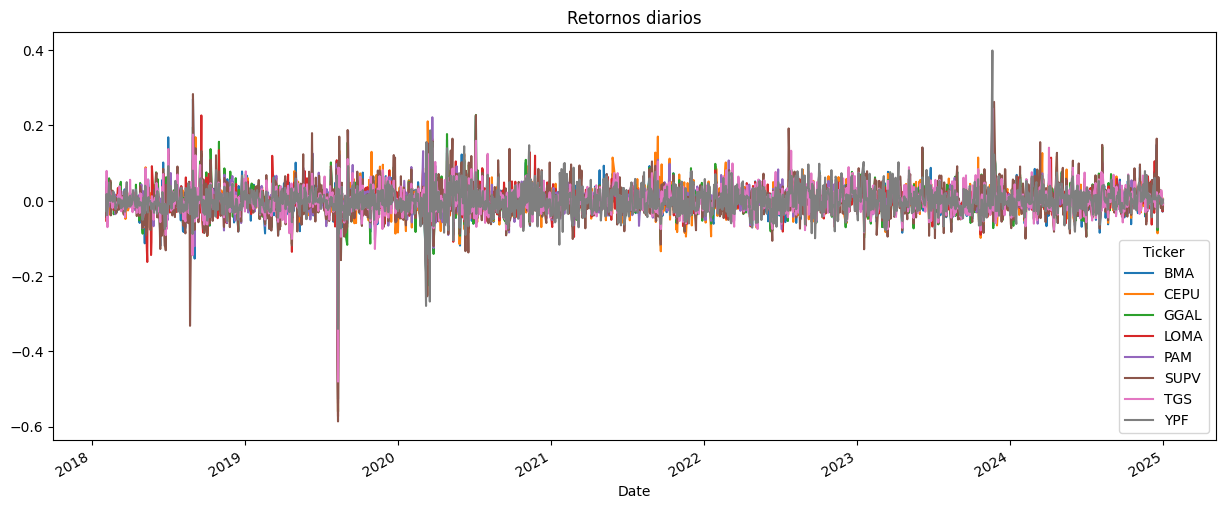

In [14]:
returns = data.pct_change().dropna()
returns.plot(figsize=(15, 6), title='Retornos diarios')
plt.show()

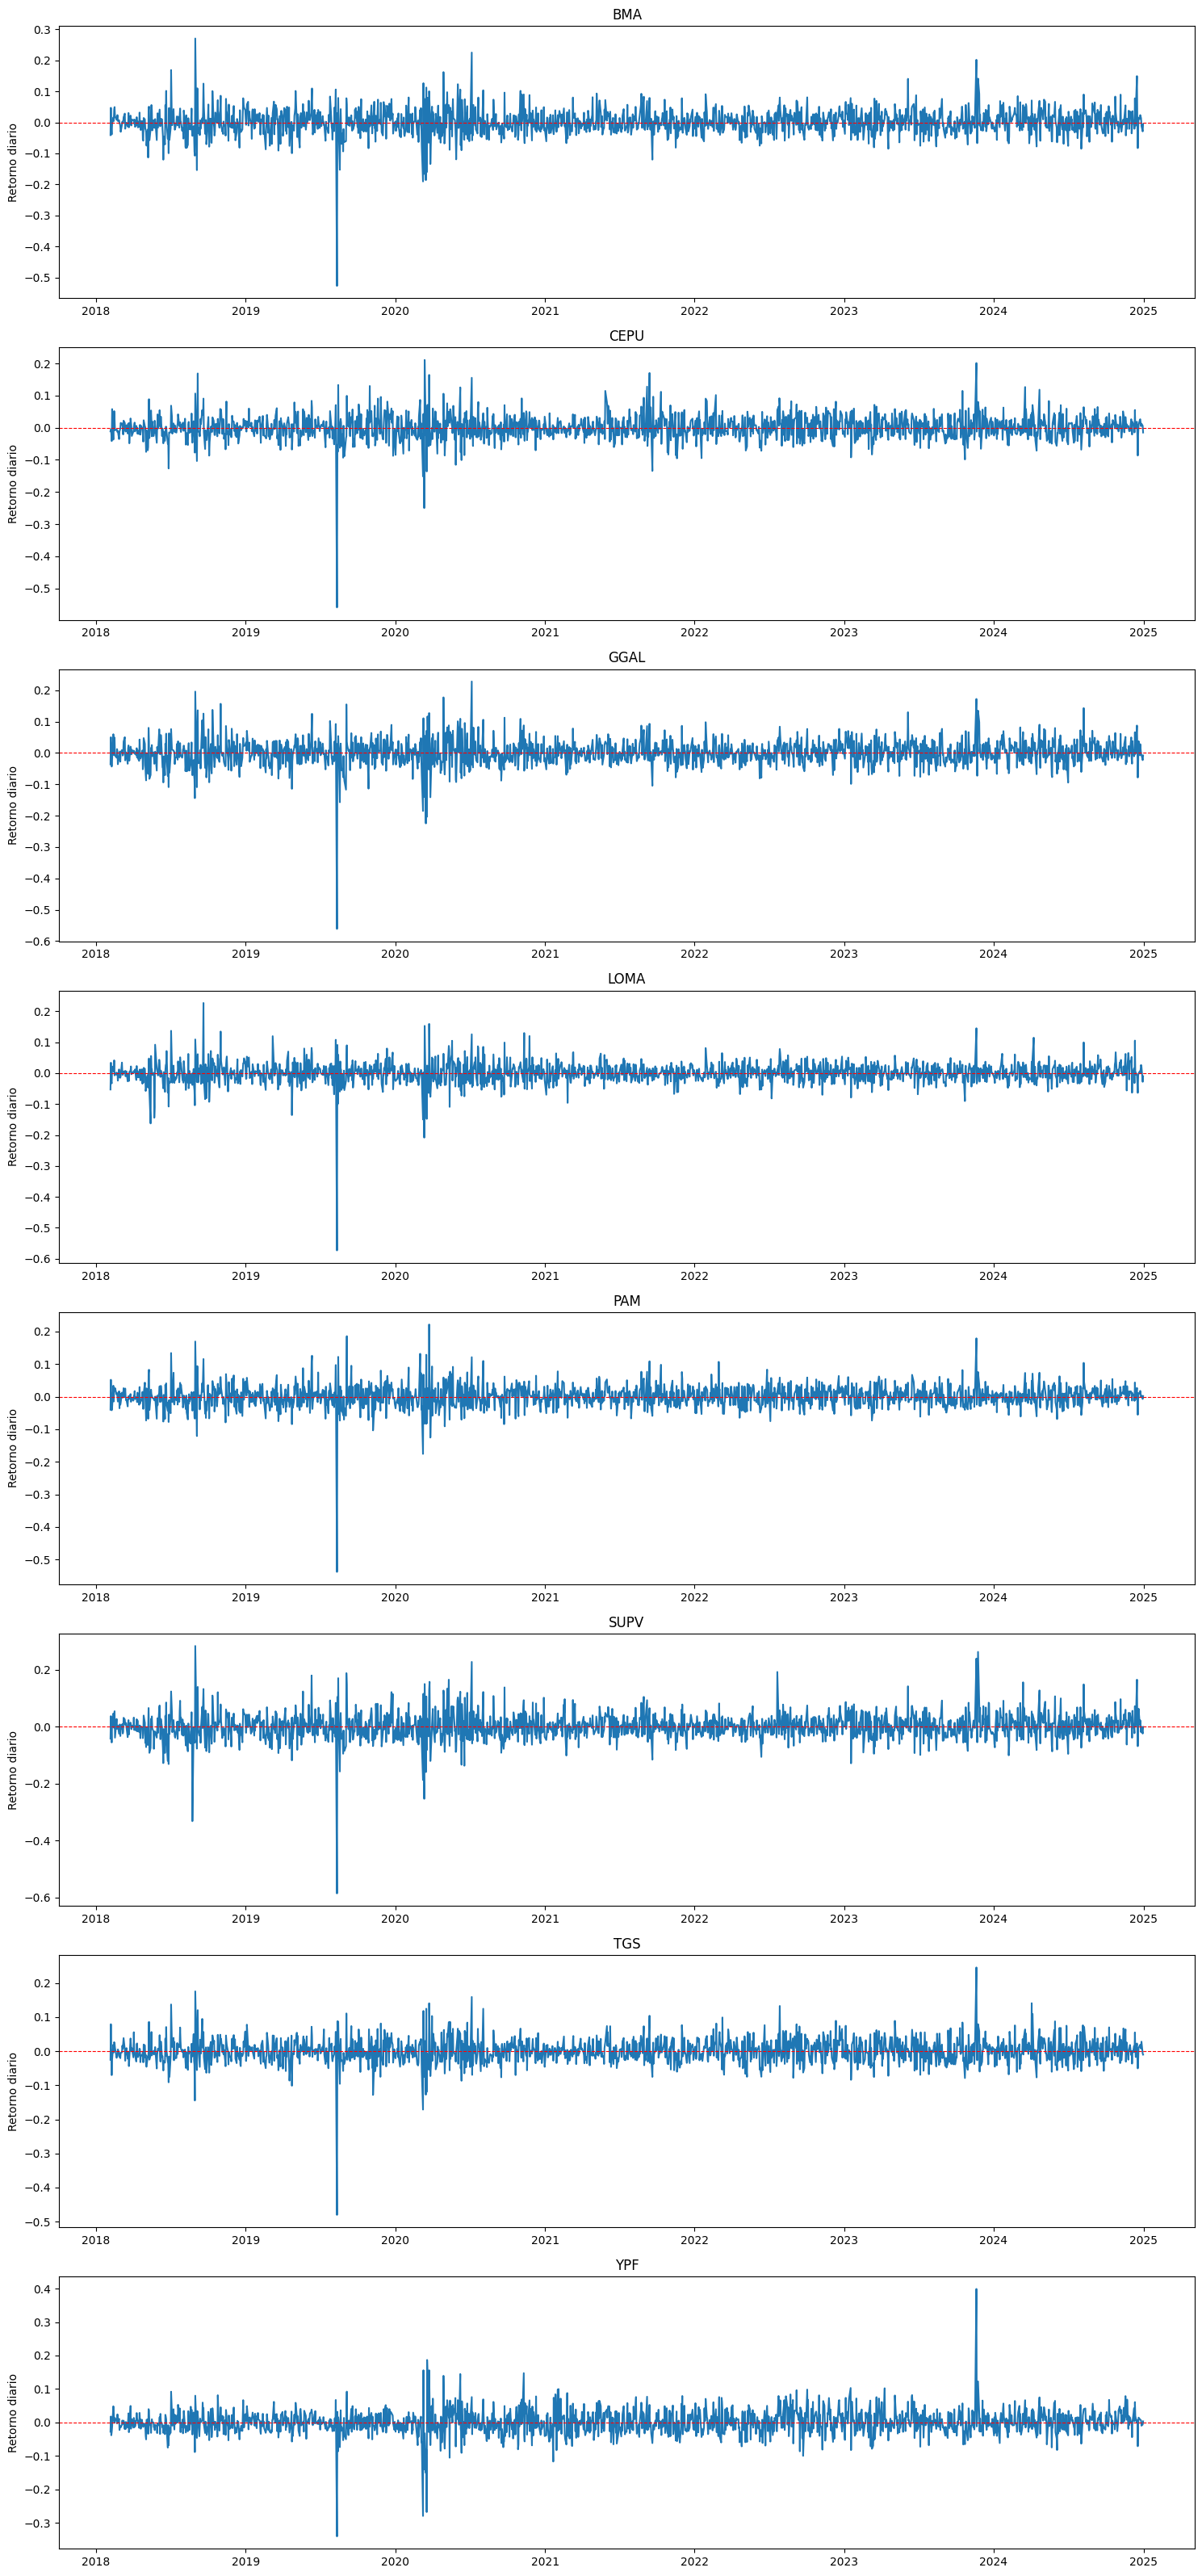

In [15]:
fig, axes = plt.subplots(len(returns.columns), 1, figsize=(15, 4 * len(returns.columns)))

for i, ticker in enumerate(returns.columns):
    axes[i].plot(returns.index, returns[ticker])
    axes[i].set_title(ticker)
    axes[i].set_ylabel('Retorno diario')
    axes[i].axhline(y=0, color='red', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

## Filtro de media movil


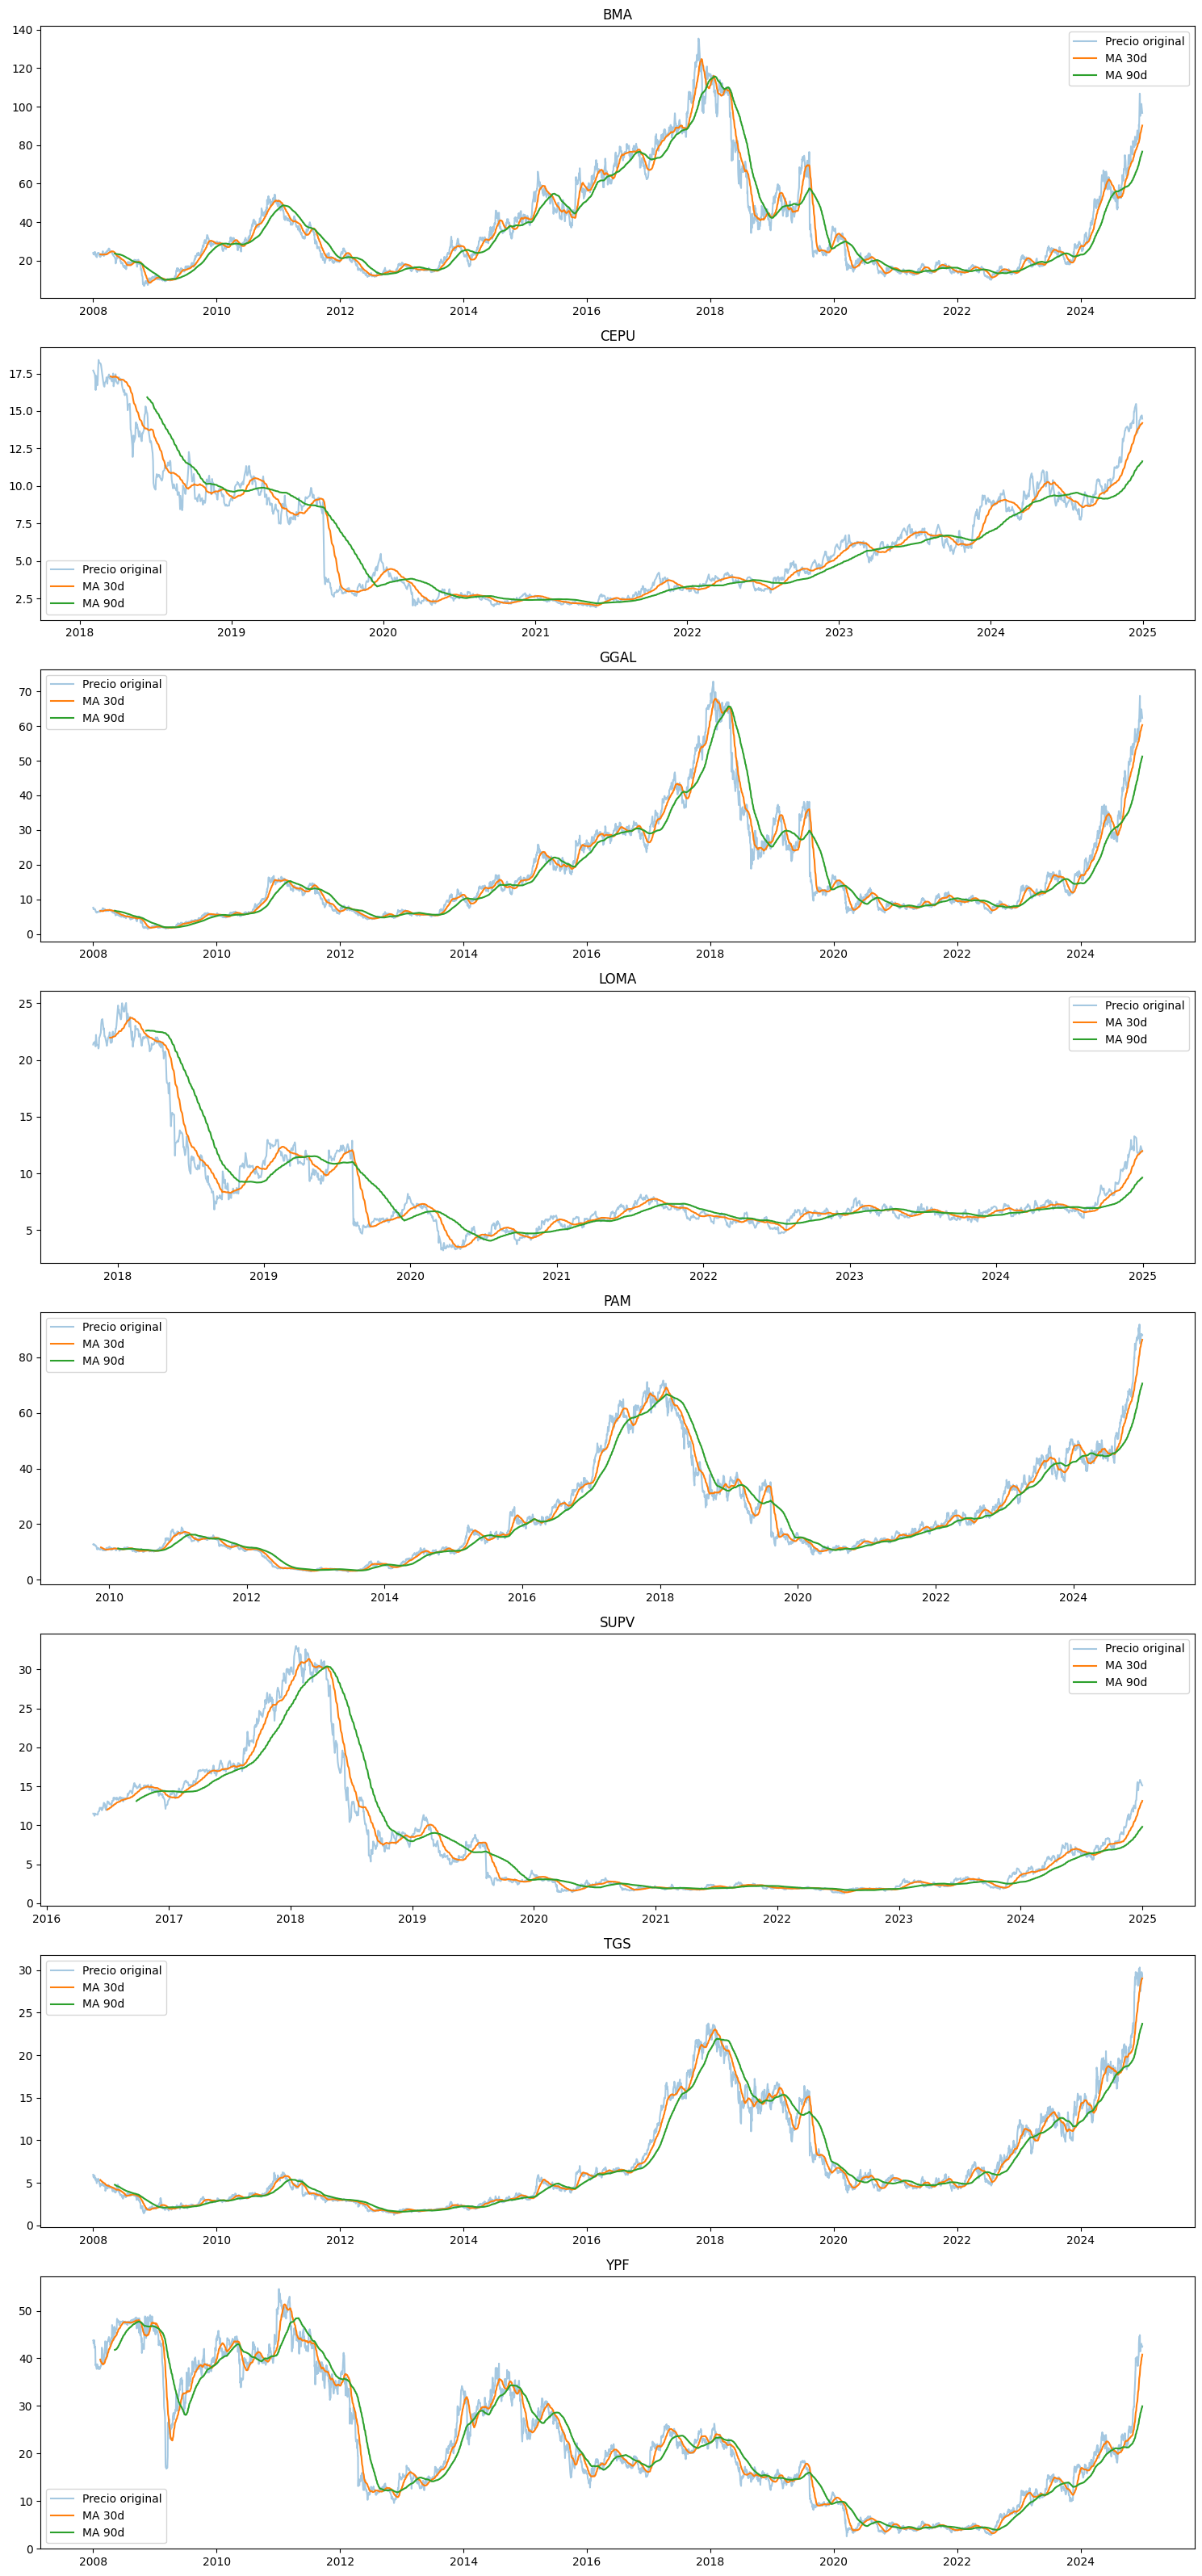

In [16]:
fig, axes = plt.subplots(len(data.columns), 1, figsize=(15, 4 * len(data.columns)))

ventanas = [30, 90]  # 1 mes y 3 meses

for i, ticker in enumerate(data.columns):
    axes[i].plot(data.index, data[ticker], alpha=0.4, label='Precio original')
    
    for ventana in ventanas:
        ma = data[ticker].rolling(window=ventana).mean()
        axes[i].plot(data.index, ma, label=f'MA {ventana}d')
    
    axes[i].set_title(ticker)
    axes[i].legend()

plt.tight_layout()
plt.show()

#### Cuando la media movil corta (30 dias) corta a las larga (90 dias) hacia arriba -> la tendencia reciente es mas fuerte que la tendencia de fondo (alcista)
#### Cuando corta habia abajo -> la reciente es mas debir que la de fondo (bajista)


##### Veo que las empresas argentinas muestran señales de estar en tendencia alcista, miestras que meli entro en bajista hace unos mesas

## Veamos la FFT y filtremos las frecuencias altas para reducir el ruido

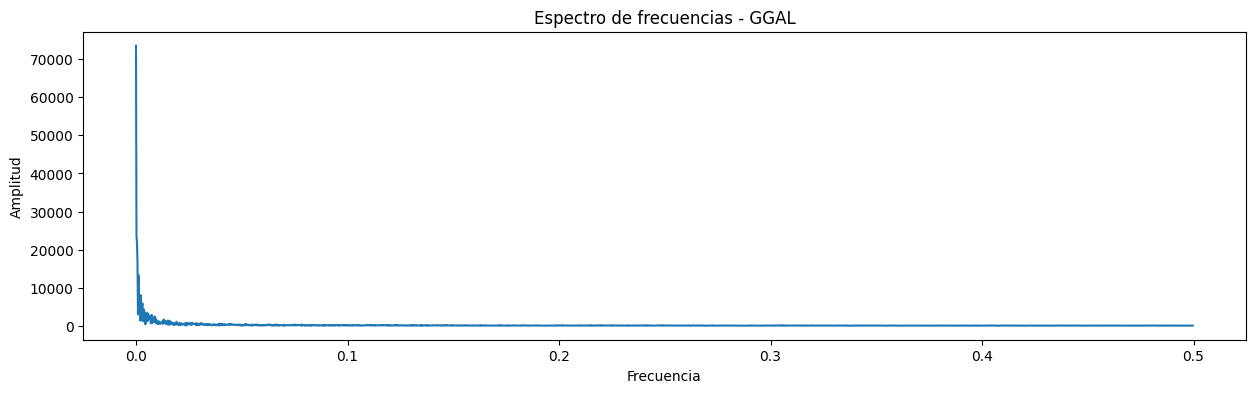

In [17]:
import numpy as np

ticker = 'GGAL'
precios = data[ticker].dropna().values

# Aplicamos FFT
fft = np.fft.fft(precios)
frecuencias = np.fft.fftfreq(len(precios))

# Graficamos el espectro de frecuencias
plt.figure(figsize=(15, 4))
plt.plot(frecuencias[:len(frecuencias)//2], 
         np.abs(fft[:len(fft)//2]))
plt.title(f'Espectro de frecuencias - {ticker}')
plt.xlabel('Frecuencia')
plt.ylabel('Amplitud')
plt.show()

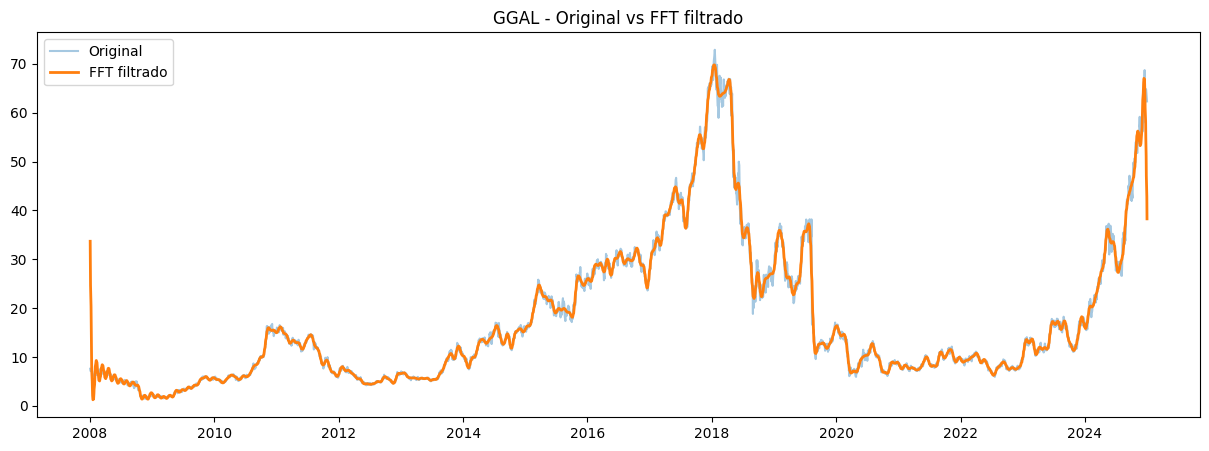

In [18]:
# Copiamos el resultado de la FFT
fft_filtrado = fft.copy()

# Umbral - eliminamos frecuencias altas
umbral = 0.04
fft_filtrado[np.abs(frecuencias) > umbral] = 0

# Reconstruimos la señal con IFFT
precio_filtrado = np.fft.ifft(fft_filtrado).real

# Comparamos original vs filtrado
plt.figure(figsize=(15, 5))
plt.plot(data.index[data[ticker].notna()], precios, alpha=0.4, label='Original')
plt.plot(data.index[data[ticker].notna()], precio_filtrado, label='FFT filtrado', linewidth=2)
plt.title(f'{ticker} - Original vs FFT filtrado')
plt.legend()
plt.show()

In [19]:
from scipy.signal import butter, filtfilt
import numpy as np

def butterworth_filter(data, cutoff, fs=1, order=4):
    nyq = fs / 2
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low')
    return filtfilt(b, a, data)

# Filtrado rolling - solo usa historia disponible hasta cada punto
fechas = data.index[data[ticker].notna()]
precios = data[ticker].dropna().values
precio_filtrado_rolling = []

for i in range(len(precios)):
    if i < 30:
        precio_filtrado_rolling.append(np.nan)
    else:
        segmento = precios[:i+1]
        filtrado = butterworth_filter(segmento, cutoff=0.05)
        precio_filtrado_rolling.append(filtrado[-1])

precio_filtrado = np.array(precio_filtrado_rolling)

# Eliminamos los primeros 30 dias
mask = ~np.isnan(precio_filtrado)
precio_filtrado = precio_filtrado[mask]
precios = precios[mask]
fechas = fechas[mask]

### con la señal filtrada puedo ver las tendencias en base a  la derivada


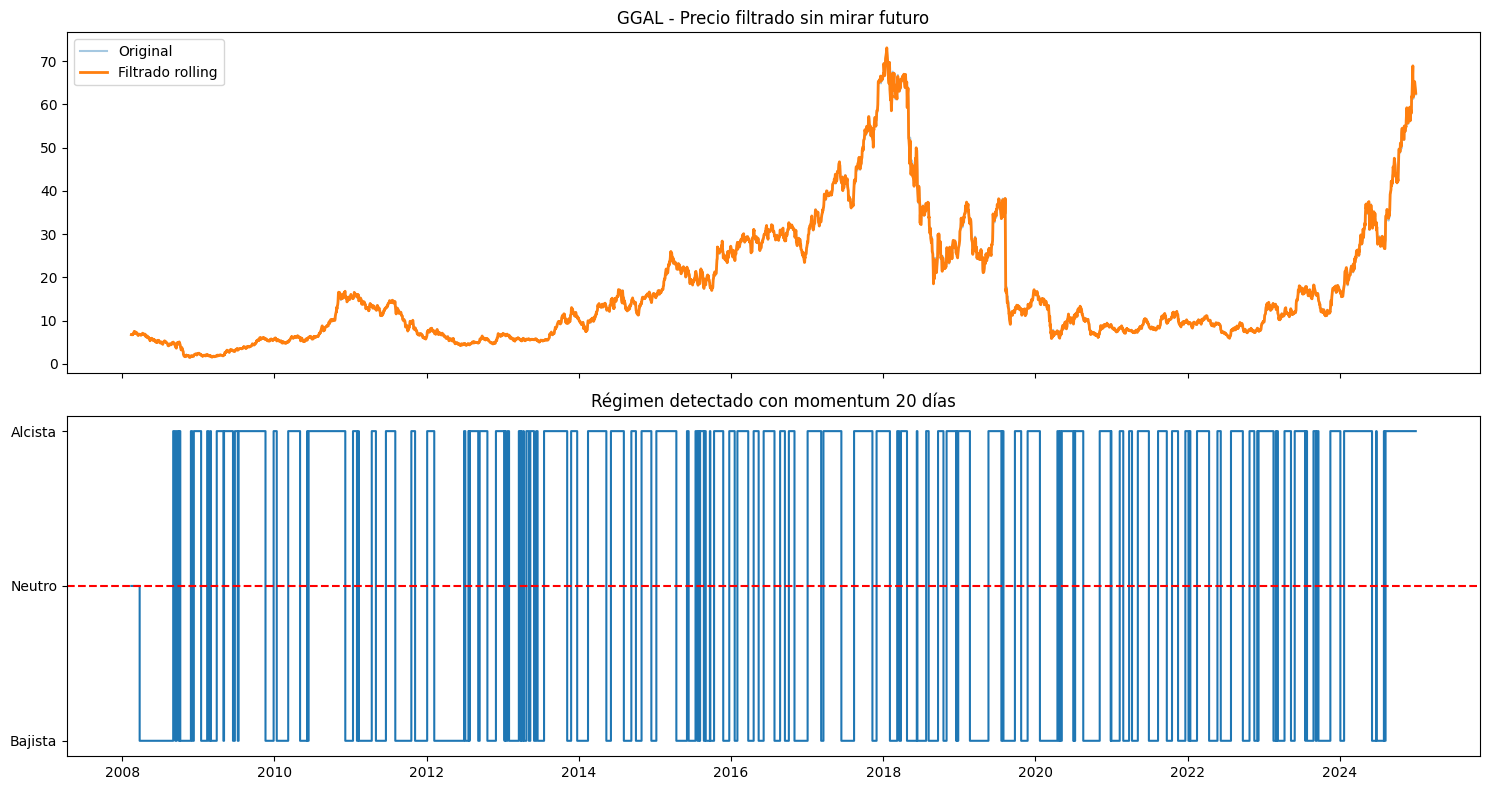

In [20]:
# Usamos el precio_filtrado rolling calculado antes
# NO volver a hacer: precio_filtrado = butterworth_filter(precios, cutoff=0.05)

precio_filtrado_s = pd.Series(precio_filtrado, index=fechas)

# Tendencia de 20 ruedas
momentum_20 = precio_filtrado_s.pct_change(20)

# Umbral: exige al menos +/- 3% en 20 ruedas para cambiar de régimen
umbral = 0.03

regimen = pd.Series(index=fechas, dtype=float)

regimen[momentum_20 > umbral] = 1
regimen[momentum_20 < -umbral] = -1

# Si está en zona neutra, mantiene el último régimen conocido
regimen = regimen.ffill()

# Al principio puede haber NaN por pct_change(20)
regimen = regimen.fillna(0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

ax1.plot(fechas, precios, alpha=0.4, label='Original')
ax1.plot(fechas, precio_filtrado, label='Filtrado rolling', linewidth=2)
ax1.set_title(f'{ticker} - Precio filtrado sin mirar futuro')
ax1.legend()

ax2.step(fechas, regimen, where='post')
ax2.axhline(y=0, color='red', linestyle='--')
ax2.set_title('Régimen detectado con momentum 20 días')
ax2.set_yticks([-1, 0, 1])
ax2.set_yticklabels(['Bajista', 'Neutro', 'Alcista'])

plt.tight_layout()
plt.show()

In [21]:
# Identificamos los cambios de regimen
regimen_values = regimen.to_numpy()

cambios = np.where(np.diff(regimen_values) != 0)[0] + 1

# Agregamos inicio y fin
breakpoints = np.concatenate([[0], cambios, [len(regimen_values)]])

# Calculamos duracion y tipo de cada regimen
regimenes = []

for i in range(len(breakpoints) - 1):
    inicio = breakpoints[i]
    fin = breakpoints[i + 1]
    duracion = fin - inicio

    tipo = regimen.iloc[inicio]

    if tipo == 1:
        tipo_nombre = 'alcista'
    elif tipo == -1:
        tipo_nombre = 'bajista'
    else:
        tipo_nombre = 'neutro'

    regimenes.append({
        'inicio': fechas[inicio],
        'fin': fechas[fin - 1],
        'duracion': duracion,
        'tipo': tipo_nombre
    })

df_regimenes = pd.DataFrame(regimenes)
print(df_regimenes)

        inicio        fin  duracion     tipo
0   2008-02-14 2008-03-24        26   neutro
1   2008-03-25 2008-08-29       112  bajista
2   2008-09-02 2008-09-11         8  alcista
3   2008-09-12 2008-09-18         5  bajista
4   2008-09-19 2008-09-26         6  alcista
..         ...        ...       ...      ...
200 2024-06-24 2024-06-25         2  alcista
201 2024-06-26 2024-07-30        24  bajista
202 2024-07-31 2024-08-01         2  alcista
203 2024-08-02 2024-08-07         4  bajista
204 2024-08-08 2024-12-31       101  alcista

[205 rows x 4 columns]


In [22]:
for tipo in ['alcista', 'bajista']:
    subset = df_regimenes[df_regimenes['tipo'] == tipo]['duracion']
    print(f"{tipo}:")
    print(f"  Promedio: {subset.mean():.1f} días")
    print(f"  Varianza: {subset.var():.1f}")
    print(f"  Mínimo:   {subset.min()} días")
    print(f"  Máximo:   {subset.max()} días")
    print(f"  Cantidad: {len(subset)} regímenes")
    print()

alcista:
  Promedio: 22.2 días
  Varianza: 563.3
  Mínimo:   1 días
  Máximo:   123 días
  Cantidad: 102 regímenes

bajista:
  Promedio: 19.2 días
  Varianza: 360.2
  Mínimo:   1 días
  Máximo:   112 días
  Cantidad: 102 regímenes



### hay mucha varianza en los regimenes alcistas como para predecir bien solo con esto cuanto tiempo va a durar

### Buscamos 

###  Features técnicas — vienen de la propia señal de precios
###  Features macro — contexto externo

Reversión a la media es la idea de que los precios (o en este caso las duraciones) tienden a volver a su promedio histórico con el tiempo.

## Construimos el dataframe completo

In [23]:
# Partimos del regimen que ya calculaste
df_features = pd.DataFrame(index=fechas)

df_features['precio'] = precios
df_features['precio_filtrado'] = precio_filtrado
df_features['regimen'] = regimen.values

# Dias transcurridos en el regimen actual
dias_en_regimen = []
contador = 0

for i in range(len(df_features)):
    if i == 0 or df_features['regimen'].iloc[i] == df_features['regimen'].iloc[i - 1]:
        contador += 1
    else:
        contador = 1
        
    dias_en_regimen.append(contador)

df_features['dias_en_regimen'] = dias_en_regimen

# Serie filtrada
precio_filtrado_s = pd.Series(precio_filtrado, index=fechas)

# Pendiente porcentual de 20 ruedas
df_features['pendiente'] = precio_filtrado_s.pct_change(20)

# Retorno diario del precio filtrado
df_features['retorno_filtrado_1d'] = precio_filtrado_s.pct_change(1)

# Desviación estándar / volatilidad de 20 ruedas
df_features['precio_std_20'] = (
    df_features['retorno_filtrado_1d']
    .rolling(20)
    .std()
)

# Target: cambia el régimen dentro de los próximos 7 días
ventana = 7
target = []

for i in range(len(df_features)):
    if i + ventana >= len(df_features):
        target.append(np.nan)
    else:
        regimen_actual = df_features['regimen'].iloc[i]
        regimen_futuro = df_features['regimen'].iloc[i+1:i+ventana+1]
        
        cambio = (regimen_futuro != regimen_actual).any()
        target.append(int(cambio))

df_features['target'] = target

df_features = df_features.dropna(subset=['target'])
df_features['target'] = df_features['target'].astype(int)

print(df_features.head())
print(df_features.shape)

            precio  precio_filtrado  regimen  dias_en_regimen  pendiente  \
Date                                                                       
2008-02-14    6.70         6.725253      0.0                1        NaN   
2008-02-15    6.69         6.715686      0.0                2        NaN   
2008-02-19    6.69         6.715039      0.0                3        NaN   
2008-02-20    6.80         6.823320      0.0                4        NaN   
2008-02-21    6.68         6.702027      0.0                5        NaN   

            retorno_filtrado_1d  precio_std_20  target  
Date                                                    
2008-02-14                  NaN            NaN       0  
2008-02-15            -0.001422            NaN       0  
2008-02-19            -0.000096            NaN       0  
2008-02-20             0.016125            NaN       0  
2008-02-21            -0.017776            NaN       0  
(4242, 8)


In [24]:
# Volumen del ticker elegido
vol_ticker = volumen[ticker].copy()
vol_ticker.index = vol_ticker.index.tz_localize(None)
vol_ticker.name = 'volumen_acciones'

df_features = df_features.join(vol_ticker, how='left')
df_features['volumen_acciones'] = df_features['volumen_acciones'].ffill()

# Features de volumen
df_features['volumen_log'] = np.log1p(df_features['volumen_acciones'])

df_features['volumen_ret_1d'] = (
    df_features['volumen_acciones']
    .pct_change(1)
)

df_features['volumen_std_20'] = (
    df_features['volumen_ret_1d']
    .rolling(20)
    .std()
)

df_features['volumen_sube'] = (
    df_features['volumen_ret_1d'] > 0
).astype(int)

# Monto negociado aproximado en USD
df_features['monto_negociado_usd'] = (
    df_features['precio'] * df_features['volumen_acciones']
)

df_features['monto_negociado_usd_log'] = np.log1p(
    df_features['monto_negociado_usd']
)

In [ ]:
# Fechas de elecciones nacionales argentinas
elecciones = pd.to_datetime([
    '2009-06-28',  # Generales 2009 (Legislativas - sin PASO)
    '2011-08-14',  # PASO 2011
    '2011-10-23',  # Generales 2011 (Presidenciales y legislativas)
    '2013-08-11',  # PASO 2013 legislativas
    '2013-10-27',  # Generales 2013 (Legislativas)
    '2015-08-09',  # PASO 2015
    '2015-10-25',  # Generales 2015 (Primera vuelta presidencial)
    '2015-11-22',  # Balotaje 2015 (Presidencial)
    '2017-08-13',  # PASO 2017 legislativas
    '2017-10-22',  # Generales 2017 (Legislativas)
    '2019-08-11',  # PASO 2019
    '2019-10-27',  # Generales 2019 (Presidenciales y legislativas)
    '2021-09-12',  # PASO 2021 legislativas
    '2021-11-14',  # Generales 2021 legislativas
    '2023-08-13',  # PASO 2023 presidenciales
    '2023-10-22',  # Generales 2023 presidenciales
    '2023-11-19',  # Balotaje 2023
    '2025-10-26',  # Generales 2025 legislativas (sin PASO)
])

tipo_eleccion = {
    '2009-06-28': 'legislativa',
    '2011-08-14': 'presidencial',
    '2011-10-23': 'presidencial',
    '2013-08-11': 'legislativa',
    '2013-10-27': 'legislativa',
    '2015-08-09': 'presidencial',
    '2015-10-25': 'presidencial',
    '2015-11-22': 'presidencial',
    '2017-08-13': 'legislativa',
    '2017-10-22': 'legislativa',
    '2019-08-11': 'presidencial',
    '2019-10-27': 'presidencial',
    '2021-09-12': 'legislativa',
    '2021-11-14': 'legislativa',
    '2023-08-13': 'presidencial',
    '2023-10-22': 'presidencial',
    '2023-11-19': 'presidencial',
    '2025-10-26': 'legislativa',
}
peso_eleccion = {
    'presidencial': 2,
    'legislativa': 0.5,
}
# Dias hasta la proxima eleccion para cada fecha
def dias_hasta_eleccion_ponderado(fecha):
    futuras = elecciones[elecciones > fecha]
    if len(futuras) == 0:
        return 999
    proxima = futuras.min()
    tipo = tipo_eleccion[str(proxima.date())]
    dias = (proxima - fecha).days
    return dias / peso_eleccion[tipo]

df_features['dias_hasta_eleccion'] = [
    dias_hasta_eleccion_ponderado(f) for f in df_features.index
]

In [26]:
# ETF argentino en USD: proxy de sentimiento hacia Argentina
argt = yf.download(
    'ARGT',
    start=start,
    end=end,
    auto_adjust=False
)['Close']

argt = argt.squeeze()
argt.index = argt.index.tz_localize(None)
argt.name = 'argt'

df_features = df_features.join(argt, how='left')
df_features['argt'] = df_features['argt'].ffill()

df_features['argt_ret_1d'] = df_features['argt'].pct_change(1)
df_features['argt_ret_5d'] = df_features['argt'].pct_change(5)
df_features['argt_sube'] = (df_features['argt_ret_1d'] > 0).astype(int)


[*********************100%***********************]  1 of 1 completed


In [27]:
# Tipo de cambio USD/ARS
usdars = yf.download(
    'ARS=X',
    start=start,
    end=end,
    auto_adjust=False
)['Close']

usdars = usdars.squeeze()
usdars.index = usdars.index.tz_localize(None)
usdars.name = 'usdars'

df_features = df_features.join(usdars, how='left')
df_features['usdars'] = df_features['usdars'].ffill()

# Features del tipo de cambio
df_features['usdars_ret_1d'] = df_features['usdars'].pct_change(1)
df_features['usdars_ret_5d'] = df_features['usdars'].pct_change(5)

df_features['usdars_std_20'] = (
    df_features['usdars_ret_1d']
    .rolling(20)
    .std()
)

[*********************100%***********************]  1 of 1 completed


In [28]:
df_features = df_features.join(gap_overnight, how='left')

df_features['gap_overnight_abs'] = df_features['gap_overnight'].abs()
df_features['gap_overnight_positivo'] = (
    df_features['gap_overnight'] > 0
).astype(int)

df_features['gap_overnight_grande'] = (
    df_features['gap_overnight_abs'] >= 0.01
).astype(int)

In [29]:
columnas_a_eliminar = [
    'precio',
    'precio_filtrado',
    'retorno_filtrado_1d',
    'volumen_acciones',
    'volumen_ret_1d',
    'monto_negociado_usd',
    'usdars',
    'argt'
]

df_features = df_features.drop(
    columns=[c for c in columnas_a_eliminar if c in df_features.columns]
)

df_features = df_features.dropna()

print(df_features.head())
print(df_features.isnull().sum())
print(df_features['target'].value_counts(normalize=True))

            regimen  dias_en_regimen  pendiente  precio_std_20  target  \
Date                                                                     
2011-03-10     -1.0               20  -0.103085       0.026357       0   
2011-03-11     -1.0               21  -0.049051       0.023776       0   
2011-03-14     -1.0               22  -0.067333       0.023662       0   
2011-03-15     -1.0               23  -0.127994       0.025792       0   
2011-03-16     -1.0               24  -0.131232       0.025890       0   

            volumen_log  volumen_std_20  volumen_sube  \
Date                                                    
2011-03-10    12.398349        1.003210             1   
2011-03-11    11.475234        0.989600             0   
2011-03-14    12.048840        0.993441             1   
2011-03-15    13.589740        1.256101             1   
2011-03-16    13.259689        1.254183             0   

            monto_negociado_usd_log  dias_hasta_eleccion  argt_ret_1d  \
Date    

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X = df_features.drop(columns=['target'])
y = df_features['target']

print(X.columns.tolist())
print(X.head())

# Split temporal - no aleatorio
split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

predictions = rf.predict(X_test)
print(classification_report(y_test, predictions))

['regimen', 'dias_en_regimen', 'pendiente', 'precio_std_20', 'volumen_log', 'volumen_std_20', 'volumen_sube', 'monto_negociado_usd_log', 'dias_hasta_eleccion', 'argt_ret_1d', 'argt_ret_5d', 'argt_sube', 'usdars_ret_1d', 'usdars_ret_5d', 'usdars_std_20', 'gap_overnight', 'gap_overnight_abs', 'gap_overnight_positivo', 'gap_overnight_grande']
            regimen  dias_en_regimen  pendiente  precio_std_20  volumen_log  \
Date                                                                          
2011-03-10     -1.0               20  -0.103085       0.026357    12.398349   
2011-03-11     -1.0               21  -0.049051       0.023776    11.475234   
2011-03-14     -1.0               22  -0.067333       0.023662    12.048840   
2011-03-15     -1.0               23  -0.127994       0.025792    13.589740   
2011-03-16     -1.0               24  -0.131232       0.025890    13.259689   

            volumen_std_20  volumen_sube  monto_negociado_usd_log  \
Date                               

In [31]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import make_scorer, recall_score

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_leaf': [1, 3, 5],
    'max_features': ['sqrt', 'log2']
}

scorer = make_scorer(recall_score)

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    scoring=scorer,
    cv=tscv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Mejores parámetros:", grid_search.best_params_)
print("Mejor recall en CV:", grid_search.best_score_)

# Evaluamos en test
best_model = grid_search.best_estimator_
predictions = best_model.predict(X_test)
print(classification_report(y_test, predictions))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Mejores parámetros: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 100}
Mejor recall en CV: 0.6049552763028461
              precision    recall  f1-score   support

           0       0.86      0.75      0.80       506
           1       0.50      0.68      0.57       188

    accuracy                           0.73       694
   macro avg       0.68      0.71      0.69       694
weighted avg       0.76      0.73      0.74       694



pendiente                  0.452932
volumen_std_20             0.077261
dias_en_regimen            0.066085
dias_hasta_eleccion        0.063836
monto_negociado_usd_log    0.054605
precio_std_20              0.052796
volumen_log                0.050093
usdars_std_20              0.045922
argt_ret_5d                0.042096
usdars_ret_5d              0.027475
gap_overnight_abs          0.014721
regimen                    0.014071
usdars_ret_1d              0.012811
argt_ret_1d                0.012062
gap_overnight              0.010139
gap_overnight_positivo     0.001284
volumen_sube               0.000866
gap_overnight_grande       0.000496
argt_sube                  0.000450
dtype: float64


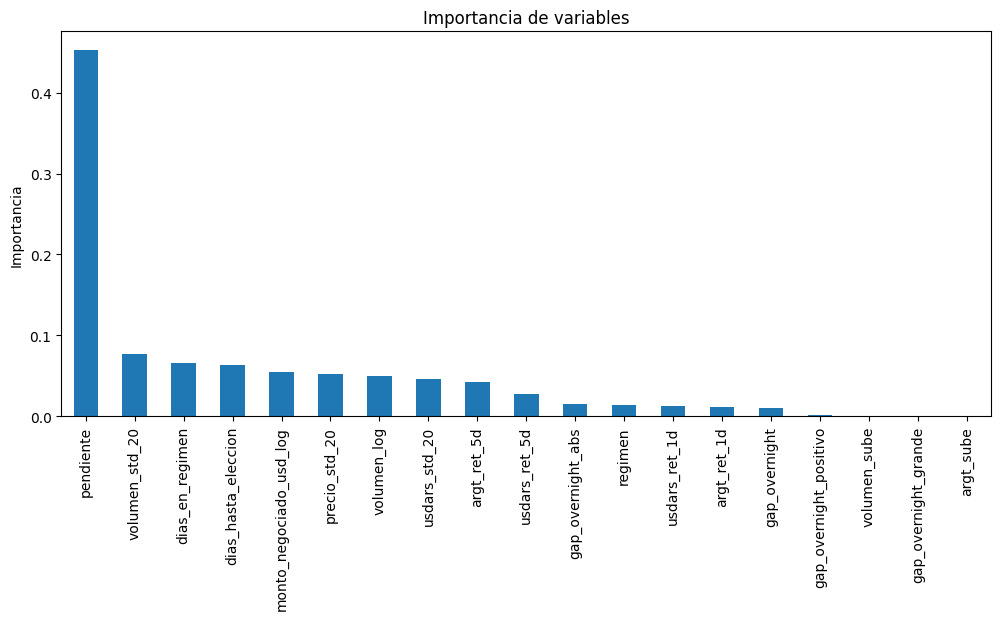

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

importancias = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importancias)

importancias.plot(kind='bar', figsize=(12, 5), title='Importancia de variables')
plt.ylabel('Importancia')
plt.show()

argentina tiene alta correlacion entre activs. si me mantengo entre activos locales cross activo no voy a conseguir mucha ventaja.

la veta es bastante similar

estaria bueno meter en el analisis el volumen(cantidad de acciones negociadas) y el tipo de cambio